# SN-ORACLE
SuperNova Occurrence and Rate Analysis from pre-Computed Large scale binary and stellar Evolutionary models

### SETUP
Load (and precompiles, if necessary) SN-ORACLE, plus all necessary packages you need to succesfully run

In [1]:
using SN_ORACLE
using Pkg

location_SNORACLE = Base.find_package("SN_ORACLE")*"/../../"
Pkg.activate(location_SNORACLE)
Pkg.instantiate()

  Activating project at `/vol/aibn133/data1/aercolino/SOFTWARE/SN-ORACLE/package`
Precompiling packages...
    806.3 ms  ✓ ColorTypes → StyledStringsExt
    615.7 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
   4151.1 ms  ✓ ColorSchemes
    585.2 ms  ✓ Colorfy
    775.0 ms  ✓ Colorfy → ColorfyUnitfulExt
   1281.0 ms  ✓ Colorfy → ColorfyDistributionsExt
  6 dependencies successfully precompiled in 10 seconds. 255 already precompiled.
  239 dependencies precompiled but different versions are currently loaded (ADTypes, ADTypes → ADTypesChainRulesCoreExt, ADTypes → ADTypesConstructionBaseExt, AbstractTrees, Accessors, Accessors → LinearAlgebraExt, Accessors → StaticArraysExt, Accessors → UnitfulExt, Adapt, Adapt → AdaptSparseArraysExt, Adapt → AdaptStaticArraysExt, AdaptivePredicates, AliasTables, ArgTools, ArrayInterface, ArrayInterface → ArrayInterfaceChainRulesCoreExt, ArrayInterface → ArrayInterfaceFillArraysExt, ArrayInterface → ArrayInterfaceSparseArraysExt, ArrayInterface → ArrayInt

In [2]:
#you still need to import the libraries you need to work with
#explicitly below

using Printf 
using StatsBase 
using CSV 
#using JLD2 
using DataFrames 

#if you need to run SN-ORACLE, be sure to load a binary grid first
f_MW = SN_ORACLE.read_hdf5_into_dataframe(SN_ORACLE.BG_dir*"master_CORR.hdf5")


@printf("Packages and Grid loaded.\n")

Reading Master CORR file /vol/aibn133/data1/aercolino/SOFTWARE/SN-ORACLE/package/src/../../Data/Models_BG/master_CORR.hdf5 ...  done
Packages and Grid loaded.


define all simulation parameters here

In [3]:
#define logM-logP-q ranges for the binary grid 
#the grid needs to be regularly spaced, there must also be 
#entries for gaps, if there are any
logMs = range(0.70, 2.001, step=0.050)
logPs = range(0.05, 3.701, step=0.050)
qs    = range(0.10, 0.951, step=0.050)


#SN_ORACLE SETTINGS
MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy" --- UNTESTED
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
EXP_CRIT         = "MM-S21" # "MM-S21"  #"Ertl-N20_new" #  "PS20"
n = 100 #number of kicks to sample after each supernova - WARNING - do not use more than ~200 as it overwhelms your RAM!
KICKS =  "Inf" # "COMBINE_n$n" # "Valli25_n$n" # "DM25_n$n"  
f_B = 0.75       #binary fraction
IMF_exponent = SN_ORACLE.alpha_m  #α in       f(M)dM ~ M^α dm
P_exponent   = 0                  #β in f(logP)dlogP ~ (logP)^β d(logP)
q_exponent   = 0                  #γ in       f(q)dq ~ q^γ dq


0

Run! 

In [4]:
🗑️ = nothing 
@printf("analyzing grid...\n")
MODELS  = nothing 
GC.gc()

MODELS, 🗑️, BH_binaries, total_SNe = do_SN_popsynth(f=f_MW,
                                             MERGER_CRITERION=MERGER_CRITERION,
                                             MERGER_EOL=MERGER_EOL, 
                                             MERGER_MASSLOSS=MERGER_MASSLOSS,
                                             EXP_CRIT=EXP_CRIT, 
                                             KICKS=KICKS,
                                             pow_m=IMF_exponent, 
                                             pow_p=P_exponent, 
                                             pow_q=q_exponent, 
                                             fB=:custom, 
                                             fB_value=f_B, 
                                             WRITE_TO_FILE=false,
                                             logPs = logPs,
                                             logMs = logMs,
                                             only_SN = false
                                             )
🗑️ = nothing 
GC.gc()

#a helpful list of all the models stored
mod_names = []
for k in keys(MODELS)
    push!(mod_names, k)
end
mod_names = sort(mod_names)

GC.gc()

#Since these runs can take quite some time, you *could* store the output [MODELS] in a 
#cache file for later, without needing to rerun everything. 
#WARNING: the files can be big! 
# out_dir = "/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/output/cache_data/CCI/"
# @printf("Exporting MODELS to a file for safekeeping")
# outfile  = out_dir * "MODELS_" * MERGER_CRITERION * "_" * EXP_CRIT * "_" * KICKS * ".jld2"
# save(outfile,  MODELS)           

@printf("done\n")

analyzing grid...
Scanning logMs
2.00 [37000/37422] 
     which |     IIP   SN87A     IIb     Ibc     IIn     Ibn (     BH)
         1 |    4.60    0.00    1.19   20.06    2.19    2.37 (   1.77) |   30.40
         2 |   15.91    0.00    0.78    2.92    0.05    0.00 (   0.99) |   19.66
         M |   24.24    0.32    1.06    3.82    0.14    0.00 (   2.66) |   29.58
         S |   16.33    0.00    1.04    2.99    0.00    0.00 (   1.56) |   20.36
     TOTAL |   61.08    0.32    4.07   29.79    2.38    2.37 (   6.98)


┌ Error: Multithreaded parsing failed and fell back to single-threaded parsing. This can happen if the input contains multi-line fields; otherwise, please report this issue.
└ @ CSV /vol/aibn133/data1/aercolino/SOFTWARE/Julia/.julia/packages/CSV/T1GBD/src/file.jl:579


prg    IIP  SN87A    IIb    Ibc    IIn    Ibn :    BH | Total
   1   4.60   0.00   1.19  20.06   2.19   2.37 :  1.77 |  30.40
   2  15.91   0.00   0.78   2.92   0.05   0.00 :  0.99 |  19.66
   M  24.24   0.32   1.06   3.82   0.14   0.00 :  2.66 |  29.58
   S  16.33   0.00   1.04   2.99   0.00   0.00 :  1.56 |  20.36
Placing non-interacting systems inside single-stars.
1-MT   0.10   0.00   1.10  17.13   2.19   2.37 :  1.60 |  22.88
2-MT  14.15   0.00   0.56   1.67   0.05   0.00 :  0.59 |  16.43
   M  24.24   0.32   1.06   3.82   0.14   0.00 :  2.66 |  29.58
S+NI  22.59   0.00   1.36   7.17   0.00   0.00 :  2.14 |  31.11
done


# Readout of the simulation output

In [17]:
#seqdata reduces the weird Dictionary structure of MODELS into a linear array
#each "star" is now an item in this list - some come from the same binary model! 

prgs, pdfs, sn1, SNe = SN_ORACLE.seqdata_MODELS("SN", mod_names, MODELS, norm_pdf=total_SNe, full_output=true)
pdfs *= 100 #better to have percentages 

#filter to only catch CCSNe 
ccsne = (SNe .== :IIP) .|| (SNe .== :Ibc) .|| (SNe .== :IIb) .|| (SNe .== :IIn) .|| (SNe .== :Ibn) .|| (SNe .== :SN87A)

#the total number of CCSNe (for normalization purposes)
sn_tot= sum(pdfs[ccsne])

#[prgs] reports where the respective star comes from 
#   MT-1 -   primary star in a mass-transferring binary
#   MT-2 - secondary star in a mass-transferring binary
#      M -    merger 
#   NI-1 -   primary star in a non-mass-transferring binary
#   NI-2 - secondary star in a non-mass-transferring binary 
#   NI-S -  a single star model 

#[pdfs] reports the (relative) supernova statistical weight of the star - sums to 100%

#[sn1] is a list of bools, detailing if the respective star was the 1st SN in its binary 
# mergers and single stars return True 

#[SNe] reports the supernova type associated to the star as symbols. 
#      :WD   -> white dwarf - no explosion 
#      :IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn 
#      :BH   -> direct collapse to BH, we assume no explosion arises 
#      :X    -> for the companions of stars that merge (the primary becomes the "merger") or TZOs

#For each star, identify the respective model number (from the binary grid list)
mod_n = SN_ORACLE.seqdata_MODELS("mod", mod_names, MODELS, full_output=false)
mods = [isnan(x) ? 1 : Int(x) for x in mod_n]


#Explosion energy, nickel mass, pre-explosion orbital separation, final mass
E_exp = SN_ORACLE.seqdata_MODELS("E_exp", mod_names, MODELS, full_output=false)
Mni = SN_ORACLE.seqdata_MODELS("M_ni", mod_names, MODELS, full_output=false)
a_pre = SN_ORACLE.seqdata_MODELS("pre_a", mod_names, MODELS, full_output=false)
Mend = SN_ORACLE.seqdata_MODELS("M_end", mod_names, MODELS, full_output=false)
#how much mass was lost after core He depletion via RLOF -> useful for interacting supernovae
dM_C = SN_ORACLE.seqdata_MODELS("dM_C", mod_names, MODELS, full_output=false)

#Baryonic and Gravitational mass of the remnant after explosion 
M_b_ns = SN_ORACLE.seqdata_MODELS("M_remnant_b", mod_names, MODELS, full_output=false)
M_g_ns = SN_ORACLE.seqdata_MODELS("M_remnant_g", mod_names, MODELS, full_output=false)
#Evaluate ejecta mass 
Mej = Mend .- M_b_ns

#Get some raw data from the binary grid in a list of same rank as the ones above  
M1hedep = f_MW.M_1_end_BURN_He_1[mods]
M1 = 10 .^ f_MW.logM[mods]
Pi = 10 .^ f_MW.logP[mods]
qi = f_MW.q[mods]
M2 = f_MW.M_2_end_1[mods]
R2 = f_MW.R_2_end_1[mods]
Y1 = f_MW.Ys_1_end_1[mods]
tot_he = f_MW.M_tot_he_1_end_1[mods] 
dM_A = f_MW.deltaM_A[mods] 
dM_B = f_MW.deltaM_B[mods] 
dM_C = f_MW.deltaM_C[mods] 

Eheat = @. SN_ORACLE.ECI.Eheat(E_exp, R2, a_pre)
Omegaeff = @. SN_ORACLE.ECI.Omega_eff(R2, a_pre)
Rmax = @.  10 ^ SN_ORACLE.ECI.logRmax(Eheat)

avg_he = (tot_he .- ( M1hedep .- Mend ))./ Mej 
Lmax = (SN_ORACLE.ECI.Lmax_analytic.(M2))
Teff_min =  @. ( Lmax/(4*π*SN_ORACLE.sigma_boltz*(Rmax*Rsun)^2) ) .^ (1/4)

for out in [:WD, :X, :IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
    @printf("%5s = %.2f%%\n", out, sum(pdfs[SNe .== out]))
end



###CCI related quantities - even though some are *companion* properties, they are still 
  # stored inside the exploding star's grid-point, so that everything belonging to one 
  # SN is stored in the same index. 
#does the binary *companion* inflate significantly during ECI, enough to undergo CCI?
R_ECI_CCI = SN_ORACLE.seqdata_MODELS("ECI?_ogata", mod_names, MODELS, full_output=false)
#how long does the *companion* star inflate after the primary explodes?
tau_ECI = SN_ORACLE.seqdata_MODELS("tau_ECI", mod_names, MODELS, full_output=false)/SN_ORACLE.day
#when is the first periastron passage after the first explosion?
tau_periastron = SN_ORACLE.seqdata_MODELS("when_will_periastron_occur", mod_names, MODELS, full_output=false)/SN_ORACLE.day
#post explosion orbital period 
P_postSN = SN_ORACLE.seqdata_MODELS("P", mod_names, MODELS, full_output=false)/SN_ORACLE.day
# what is the post-explosion orbit? :bound, :unbound, ....
post_SN_orbit = SN_ORACLE.seqdata_MODELS("orbit", mod_names, MODELS, full_output=false)
eccentricity = SN_ORACLE.seqdata_MODELS("e", mod_names, MODELS, full_output=false)
v_kick = SN_ORACLE.seqdata_MODELS("1st_kick", mod_names, MODELS, full_output=false)
v_orb_1 = SN_ORACLE.seqdata_MODELS("pre_v1", mod_names, MODELS, full_output=false)
first_CO = SN_ORACLE.seqdata_MODELS("1stCO", mod_names, MODELS, full_output=false)
n_passages = [post_SN_orbit[i] == :bound ? (floor((tau_ECI[i] - tau_periastron[i])/P_postSN[i]) + 1) : 1   for i in range(1,length(pdfs))]

#SNe that undergo CCI have to be the first one, identified as a CCSN, and must satisfy  R2<r_peri<R_max [Ercolino+2026b]
select_sne = sn1 .&& ccsne #only first SNe
can_do_CCI = R_ECI_CCI .&& sn1 .&& ccsne  #first SNe with CCI
CCI = can_do_CCI .&& (tau_periastron .< tau_ECI)

#Double-check, should not return false 
for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "M", "NI-S"]
    @printf("%5s = %.2f%%\n", prg, sum(pdfs[(prgs .== prg) .&& ccsne]))
end
boolprg = (prgs .== "MT-1") .|| (prgs .== "NI-1") .|| (prgs .== "MT-2") .|| (prgs .== "NI-2") .|| (prgs .== "M") .|| (prgs .== "NI-S")
(false in boolprg) && throw(ErrorException)
@printf("Data Collection complete\n")

Getting data for SN...
Getting data for mod...
Getting data for E_exp...
Getting data for M_ni...
Getting data for pre_a...
Getting data for M_end...
Getting data for dM_C...
Getting data for M_remnant_b...
Getting data for M_remnant_g...
   WD = 231.76%
    X = 0.23%
  IIP = 61.08%
SN87A = 0.32%
  IIb = 4.07%
  Ibc = 29.79%
  Ibn = 2.37%
  IIn = 2.38%
Getting data for ECI?_ogata...
Getting data for tau_ECI...
Getting data for when_will_periastron_occur...
Getting data for P...
Getting data for orbit...
Getting data for e...
Getting data for 1st_kick...
Getting data for pre_v1...
Getting data for 1stCO...
 MT-1 = 22.88%
 NI-1 = 7.52%
 MT-2 = 16.43%
 NI-2 = 3.23%
    M = 29.58%
 NI-S = 20.36%
Data Collection complete


# Examples

In [13]:
#Extra useful plot functions are included here 

include("Plot_defs.jl")


Including Graphical Packages...Setting LaTeX Theme...done!
done!


## Mej distribution for Type Ibc supernovae
this plot here replicates the figure in Ercolino+2026 for the distribution of ejecta masses in Type Ibc supernovae, color coded by whether they are donor star, accretors, merger products or (effectively) single stars.
To obtain the same exact copy, be sure to run the popsynth code with no kicks (i.e., "Inf"). Otherwise you will see an increase in contribution of secondaries to the low-mass peak (which is expected)

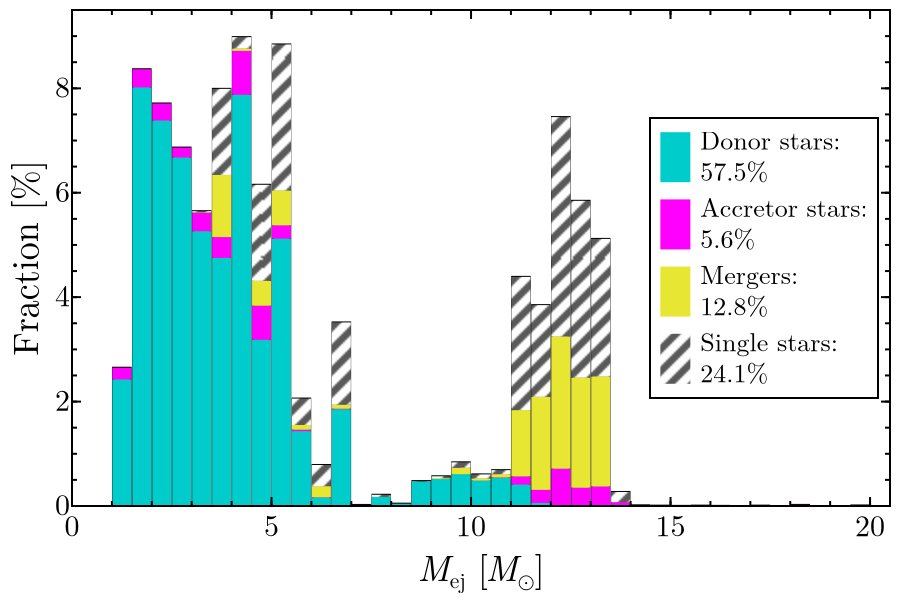

In [14]:
FIG = Figure(size=(450, 300), figure_padding = 5)
ax = plot_settings( FIG[1,1],
                xlabel = L"M_\mathrm{ej} \ [M_\odot]",
                ylabel =  "Fraction [%]",
                title = "", 
                xticks = 0:5:100,
                xmticks = 0:1:100,
                yticks= 0:2:100,
                ymticks= 0:0.5:100,
                xlabelsize=18,
                ylabelsize=18,
)

alpha=1
color_coding = Dict()
color_coding[:RLOF1] = RGBAf(0,0.8,0.8 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(0.9,0.9,0.2 ,alpha)   
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 100, spacing=11, thickness=2,
                        style=style, line_color=color,
                        bg_color= color2)
color_coding[:NI]    = Pattern(colorhatch(RGBAf(.35, .35, .35 ,alpha) ,color2=RGBAf(1.,1.,1.,1), style = :slash))

x = Mej
fff = (SNe .== :Ibc)
p = pdfs ./ sum(pdfs[fff]) .*100

xbins = 0:0.5:100
dxb = 0.5
pri = prgs .== "MT-1"
sed = prgs .== "MT-2"
mer = prgs .== "M"
sng = (prgs .== "NI-1") .|| (prgs .== "NI-2") .|| (prgs .== "NI-S")
bins, y_bins = run_histogram(ax, x[fff],         p[fff],         xbins, dxb, norm=1, to_plot = true)
_,    y_1    = run_histogram(ax, x[fff .&& pri], p[fff .&& pri], xbins, dxb, norm=1, to_plot = false)
_,    y_2    = run_histogram(ax, x[fff .&& sed], p[fff .&& sed], xbins, dxb, norm=1, to_plot = false)
_,    y_M    = run_histogram(ax, x[fff .&& mer], p[fff .&& mer], xbins, dxb, norm=1, to_plot = false)
_,    y_S    = run_histogram(ax, x[fff .&& sng], p[fff .&& sng], xbins, dxb, norm=1, to_plot = false)

stacked_barplot!(ax, bins, [y_1, y_2, y_M, y_S],
                width = dxb/1.05, colors = [color_coding[:RLOF1], color_coding[:RLOF2], color_coding[:M], color_coding[:NI]] )
barplot!(ax, [NaN], color = color_coding[:RLOF1], label = @sprintf("Donor stars:\n%.1f%%", sum(pdfs[SNe .== :Ibc .&& prgs .== "MT-1"])/sum(pdfs[SNe .== :Ibc]) * 100 ))
barplot!(ax, [NaN], color = color_coding[:RLOF2], label = @sprintf("Accretor stars:\n%.1f%%", sum(pdfs[SNe .== :Ibc .&& prgs .== "MT-2"])/sum(pdfs[SNe .== :Ibc]) * 100 ))
barplot!(ax, [NaN], color = color_coding[:M], label = @sprintf("Mergers:\n%.1f%%", sum(pdfs[SNe .== :Ibc .&& mer])/sum(pdfs[SNe .== :Ibc]) * 100 ))
barplot!(ax, [NaN], color = color_coding[:NI], label = @sprintf("Single stars:\n%.1f%%", sum(pdfs[SNe .== :Ibc .&& sng])/sum(pdfs[SNe .== :Ibc]) * 100 ))
axislegend(ax,  position=:rc, 
        nbanks= 1, titleposition=:left, rowgap=5,colgap=0, 
        labelsize=13, padding=(5,5,5,5), framevisible=true,
        patchsize=[15,25])

ylims!(ax, 0,9.5)
xlims!(ax, 0,20.5)
#save(DIRECTORY, FIG)
FIG

## Pie Charts

SN_numbers: tot 100.000 - sub 100.000
SN_numbers: tot 22.884 - sub 22.884
SN_numbers: tot 16.426 - sub 16.426
SN_numbers: tot 29.579 - sub 29.579
SN_numbers: tot 31.111 - sub 31.111


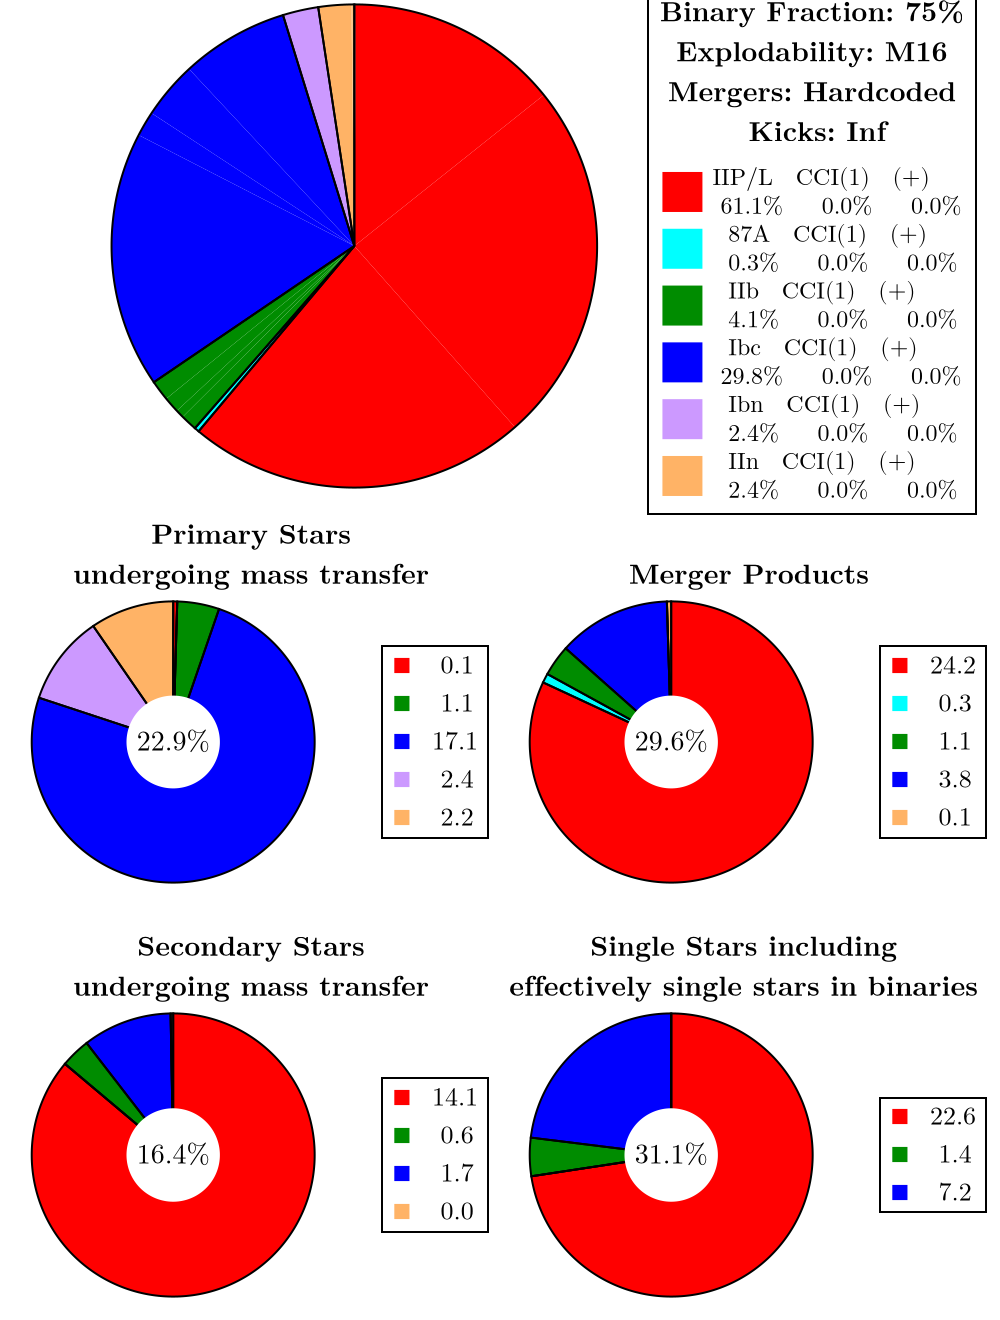

In [15]:

FIG = Figure(size=(500, 660), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")

ax_pie[:RLOF1] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars\nundergoing mass transfer")

ax_pie[:RLOF2] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars\nundergoing mass transfer")


ax_pie[:M] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie[:NI] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars including \neffectively single stars in binaries ")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn, :BH]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["MT-1", "MT-2",  "M", "NI-1", "NI-2", "NI-S"]
sntypes_to_print =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
sntypes_to_plot  =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
progenitors_int_and_non = [:RLOF1, :RLOF2,  :M, :NI]


alpha = 1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

prg_interface = Dict("MT-1"=>:RLOF1, "MT-2"=>:RLOF2, "M"=>:M,
                     "NI-1"=>:NI, "NI-2"=>:NI, "NI-S"=>:NI)
sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")
prgs2 = [ prg_interface[prg] for prg in prgs]
for sn in sntypes 
    color_coding_new[sn]=Dict()
    for prg in progenitors_int_and_non
        color_coding_new[sn][prg] = Dict()
        color_coding_new[sn][prg][:more] = Pattern(colorhatch(color_coding[sn], color2=RGBAf(0.,0.,0.,1)))
        color_coding_new[sn][prg][:one]  = Pattern(colorhatch(color_coding[sn]))
        color_coding_new[sn][prg][:none] = color_coding[sn]
    end
end

colores = [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_int_and_non]
n_to_sym(array) = [ x == 1  ? :one : (x==0 ? :none : :more) for x in array]
N_CCI = n_to_sym(n_passages)
track_eci = true


function sn_pie_chart(ax, pdfs, prgs, sne, condition; track_eci=false, r_in = 0, r_out = 1)

    SN_numbers = [sum(pdfs[ (sne .== sn) .&&  condition]) 
                        for sn in sntypes_to_plot]

    SN_numbers_sub = [ sum(pdfs[ (sne .== sn) .&& 
                                 (prgs .== prg) .&& 
                                 condition .&& 
                                 ( (!track_eci .&& (eci .== :none)) .||
                                   ( track_eci .&& 
                                       (( (CCI .== true ) .&& (N_CCI .== eci) ) .||
                                        ( (CCI .== false) .&& (eci == :none) )) )
                                    ) ])  
                        for sn in sntypes_to_plot 
                        for eci in [:none, :one, :more]
                        for prg in progenitors_int_and_non]
    SN_colors_sub =  Any[color_coding_new[sn][prg][track_eci ? eci : :none]
                        for sn in sntypes_to_plot 
                        for eci in [:none, :one, :more]
                        for prg in progenitors_int_and_non]
    
    @printf("SN_numbers: tot %5.3f - sub %5.3f\n", sum(SN_numbers), sum(SN_numbers_sub))
    abs(sum(SN_numbers) - sum(SN_numbers_sub)) > 1e-8 && throw(ErrorException("Something went wrong in pie chart: check logic!"))

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    normer = sum(SN_numbers_sub)

    return normer 

end


sn_pie_chart(ax_pie["all"], pdfs, prgs2, SNe, ccsne; track_eci=track_eci)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in progenitors_int_and_non

    # prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], pdfs, prgs2, SNe, ccsne .&& (prgs2 .== tt); track_eci = track_eci )
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        sumpdfs = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn)])
        sumpdfs < 1e-6 && continue
        sumpdfs1 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn) .&& (CCI) .&& (N_CCI .== :one) ])
        sumpdfs2 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn) .&& (CCI) .&& (N_CCI .== :more)  ])

        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f", sumpdfs) * (track_eci && sumpdfs1+sumpdfs2>1e-3 ? @sprintf(" (%4.1f+%4.1f)", sumpdfs1, sumpdfs2) : "") )
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks= 1, titleposition=:left, rowgap=-1,colgap=0, 
                labelsize=13, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false

for sn in sntypes_to_print
    sumpdfs = sum(pdfs[ SNe .== sn])
    sumpdfs1 = sum(pdfs[ SNe .== sn .&& CCI .&& (N_CCI .== :one)  ])
    sumpdfs2 = sum(pdfs[ SNe .== sn .&& CCI .&& (N_CCI .== :more) ])
    barplot!(ax_pie["all"], [-100], [0], color = color_coding[sn],   
        label = @sprintf("%5s \t %s \t %s\n%5.1f%% \t %5.1f%% \t %5.1f%%",
             sn_interface[sn], track_eci ? "CCI(1)" : " ", track_eci ? "(+)" : " ",
             sumpdfs, track_eci ? sumpdfs1 : " ", track_eci ? sumpdfs2 : " " ))
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )
kick_crit = KICKS
key_label = @sprintf( "Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\n Kicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

axislegend(ax_pie["all"], key_label, position=:rc, 
    nbanks=1, labelsize=12, rowgap =2, colgap =8, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



 
resize_to_layout!(FIG)


#save(DIRECTORY, FIG)

FIG

 

## break-up of contribution channels of different SNe
A useful tree-diagram diagnostic

In [16]:
SN_companion = Dict()
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
    SN_companion[ttp] = Dict()
    for companion in [:MS_bound, :MS_unbound, :CO, :X, :TZO]
        SN_companion[ttp][companion] = Dict("pdf"=>-1e-16, "CCI"=>-1e-16, "CCI+"=>-1e-16)
    end
end

map_state(state) = Dict(:bound=>:bound, :unbound=>:unbound, :unknown=>:unbound, :direct_collision=>:TZO)[state]

function dissector(fff; pdfs=pdfs, extratab="\t\t")
    for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "M", "NI-S"]
        n=sum(pdfs[fff .&& prgs .== prg])
        n>0.001 && @printf("%s %5s   (%4s) = %5.3f\n", "", extratab, prg,n)
    end
end

for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn]

    filter_all = (SNe .== ttp) 
    filter_first = filter_all .&& sn1 
    filter_first_w_comp  = filter_first .&& .! (prgs .== "M" .||  prgs .== "NI-S") 
    filter_first_no_comp = filter_first .&&    (prgs .== "M" .||  prgs .== "NI-S") 
    @printf("\n%5s:  %6.2f\n", ttp, sum(pdfs[filter_all]))
    @printf("%5s   first    = %6.2f\n", "", sum(pdfs[filter_first]))
    @printf("\t %5s S/M = %6.2f\n", "", sum(pdfs[filter_first_no_comp]))
    SN_companion[ttp][:X]["pdf"]  = sum(pdfs[filter_first_no_comp])
    SN_companion[ttp][:X]["CCI"]  = 0.
    SN_companion[ttp][:X]["CCI+"] = 0.
    dissector(filter_first_no_comp)
    
    @printf("\t %5s bin = %6.2f\n", "", sum(pdfs[filter_first_w_comp]))
    dissector(filter_first_w_comp)
    
    for state in reverse([:bound, :unbound, :direct_collision, :unknown])
        filter_state = filter_first_w_comp .&& post_SN_orbit .== state
        filter_cci = filter_state .&& CCI
        filter_cci_p = filter_cci .&& (n_passages .> 1)
        n     = sum(pdfs[filter_state])
        nCCI  = sum(pdfs[filter_cci])
        nCCIp = sum(pdfs[filter_cci_p])
        mapped = nothing 
        (map_state(state) == :bound)   && (mapped = :MS_bound)
        (map_state(state) == :unbound) && (mapped = :MS_unbound)
        (map_state(state) == :TZO)     && (mapped = :TZO)
        SN_companion[ttp][mapped]["pdf"]  += n
        SN_companion[ttp][mapped]["CCI"]  += nCCI
        SN_companion[ttp][mapped]["CCI+"] += nCCIp
        n > 0.001 && @printf("\t\t%20s:%5.2f\n", state, n)
        dissector(filter_state, extratab="\t\t\t")
        nCCI > 0.001 && @printf("\t\t\t\t CCI:%5.2f\n",nCCI) 
        dissector(filter_cci, extratab="\t\t\t\t")
        nCCIp > 0.001 && @printf("\t\t\t\t\t CCI+:%5.2f\n",nCCIp)
        dissector(filter_cci_p, extratab="\t\t\t\t\t")

    end

    filter_second = filter_all .&& .! sn1 
    @printf("%5s   2nd   = %6.2f\n", "", sum(pdfs[filter_second]))
    filter_degB = filter_second .&& post_SN_orbit .== :bound 
    n_degB = sum(pdfs[filter_degB])
    SN_companion[ttp][:CO]["pdf"]  += n_degB
    SN_companion[ttp][:CO]["CCI"]  += 0.
    SN_companion[ttp][:CO]["CCI+"] += 0.
    n_degB > 0.001 && @printf("\t\t\t%12s:%5.2f \n", "deg-bound", n_degB)
    dissector(filter_degB)

    filter_degUnb = filter_second .&& (post_SN_orbit .== :unbound .|| post_SN_orbit .== :unknown)  
    n_degUnb = sum(pdfs[filter_degUnb])
    SN_companion[ttp][:X]["pdf"]  += n_degUnb
    SN_companion[ttp][:X]["CCI"]  += 0.
    SN_companion[ttp][:X]["CCI+"] += 0.
    n_degUnb > 0.001 && @printf("\t\t\t%12s:%5.2f \n", "deg-unbound", n_degUnb)
    dissector(filter_degUnb)

end

@printf("\n\nIn short\n\n")
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
    for companion in [:MS_bound, :MS_unbound, :CO, :X, :TZO]
        SN_companion[ttp][companion]["pdf"] > 0.001 && @printf("%5s  -  %10s  -  tot=%7.3f [CCI: %5.3f (+: %5.3f)]\n", 
        ttp, companion, SN_companion[ttp][companion]["pdf"], SN_companion[ttp][companion]["CCI"], SN_companion[ttp][companion]["CCI+"])
    end
end


  IIP:   61.08
        first    =  45.17
	       S/M =  40.57
      		   (   M) = 24.244
      		   (NI-S) = 16.328
	       bin =   4.60
      		   (MT-1) = 0.105
      		   (NI-1) = 4.492
		             unbound: 4.60
      			   (MT-1) = 0.105
      			   (NI-1) = 4.492
        2nd   =  15.91
			   deg-bound: 0.66 
      		   (MT-2) = 0.591
      		   (NI-2) = 0.065
			 deg-unbound:15.26 
      		   (MT-2) = 13.557
      		   (NI-2) = 1.700

SN87A:    0.32
        first    =   0.32
	       S/M =   0.32
      		   (   M) = 0.316
	       bin =   0.00
        2nd   =   0.00

  IIn:    2.38
        first    =   2.33
	       S/M =   0.14
      		   (   M) = 0.144
	       bin =   2.19
      		   (MT-1) = 2.188
		             unbound: 2.19
      			   (MT-1) = 2.188
        2nd   =   0.05
			   deg-bound: 0.05 
      		   (MT-2) = 0.048

  IIb:    4.07
        first    =   3.29
	       S/M =   2.10
      		   (   M) = 1.056
      		   (NI-S) = 1.044
	       bin =   1.19
      		   (MT-1) = 

## Cornerplots

In [ ]:
mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100

bin_scale = 25 
ticksize=12
FIGURE = Figure(size=(400,400).*0.8, figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[3,2e3], 
                 "T"=>[35,2e4], 
                 "N"=>[.666,2e3],
                 "e"=>[0,0.999],
                 "Mej"=>[0.1,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,49],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,2e41],
                 "a_pre"=>[6,600],
                 "Teff"=>[2.5,10.5],
                 "Y"=>[.05,1.1])
val_scale = Dict("P"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10, "Y"=>identity,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10, "Teff"=>identity)

vals        = copy(cached_file)
vals["pdf"] = cached_file["pdf"]/sum(cached_file["pdf"]) *100
vals["Teff"]= cached_file["Teff"] ./ 1e3
vals["Y"] = cached_file["Y1"]
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Y"=>(0.2:0.3:1, 0.:0.1:1),
                 "e"=>(0.2:0.3:1.0, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "Teff"=>(1.:2:10, 0.:0.5:10.0),
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{infl} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{inter}",
                 "Y"=>L"Y_\mathrm{pre-SN}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e_\mathrm{post-SN}",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "Teff"=>L"T_\mathrm{eff} \ [\mathrm{kK}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff} \ [\mathrm{strad}/4\pi]")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Y"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Teff"=>0,
                 "Omega"=>4)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>0.3, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing, "Teff"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"Y"=>0.066666, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[540, :lowerlimit], 
                        "Y"=>[0.5, :upperlimit], "Teff"=>[NaN, :unknown],
                     "N"=>[floor(540/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.5, :lowerlimit],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown],
                     "color"=>:orange, "Lmax"=>[1e40, :upperlimit])
SN2015ap     = Dict("P"=>[8.41, 0.08], "T"=>[150, :lowerlimit], 
                        "Y"=>[0., :upperlimit], "Teff"=>[NaN, :unknown],
                     "N"=>[floor(150/8.41), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[2.2, 0.6],
                     "S"=>[NaN,:unknown], "e"=>[NaN, :lowerlimit],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown],
                     "color"=>:cyan, "Lmax"=>[1e41, :upperlimit])
SN2022esa     = Dict("P"=>[32, 4], "T"=>[190, :lowerlimit], 
                        "Y"=>[0., :upperlimit], "Teff"=>[NaN, :unknown],
                     "N"=>[floor(190/32), :lowerlimit, :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[NaN, :lowerlimit],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown],
                     "color"=>:magenta, "Lmax"=>[NaN, :unknown])
mycmap = cgrad([:gray95,:gray70, :skyblue3, :green2, :yellow, :red,  :black], 
                [0,0.05,    0.15,  0.3,     0.5,  0.7,       1])
colorrange=[1e-10,3]
#ptjsn
variables    = ["P", "e", "N"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]


                
for cornerplot in cornerplots
        # print("Setting up plot: ", cornerplot, " at pos ", positions[x], "-", positions[y], "\n")
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:1:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)

hm = nothing  


BeXRBs_Valli = CSV.read("/vol/aibn133/data1/aercolino/CATALOGUES/Valli25_BeXRB.data", DataFrame, delim=' ',ignorerepeated=true)

for cornerplot in cornerplots
        print(cornerplot, "\n")
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = !isnothing(dbins[xlab]) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/bin_scale
        dyb = !isnothing(dbins[ylab]) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/bin_scale
        dxb = (scalex(xmax)-scalex(xmin))/bin_scale
        dyb = (scaley(ymax)-scaley(ymin))/bin_scale

        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        print("[x] bins: ", xbins, "; vals: ", minimum(x), "-", maximum(x), "\n")
        print("[y] bins: ", ybins, "; vals: ", minimum(y), "-", maximum(y), "\n")
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black, lowclip=:white)

        if xlab == "P" && ylab == "e"
                scatter!(ax[cornerplot], scalex.(BeXRBs_Valli.P), scaley.(BeXRBs_Valli.e), color = [e .> 0.25 ?  :blue : :red for e in BeXRBs_Valli.e], markersize = 5, marker = :+)
        end

        # PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        # text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        # position = (.85, .95),        # relative coords in axis space
        # align = (:right, :top),   # anchor point
        # space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )
        for sn in [SN2022jli, SN2015ap, SN2022esa]
                if sn[xlab][2] == :lowerlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (1, 0),
                        lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[ylab][2] == :lowerlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (0, 1),
                        lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[xlab][2] == :upperlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (-1, 0),
                        lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[ylab][2] == :upperlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (0, -1),
                        lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                scatter!(ax[cornerplot], scalex.(sn[xlab][1]), scaley(sn[ylab][1]), marker = :star5, color=sn["color"], strokecolor=:black, strokewidth=1 )

        end
        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end

SN_FILE = CSV.read("../output/ECI_detailed_new3.dat", DataFrame, delim=" ", ignorerepeated=true )
function get_match_from_database(k,m,e,f=SN_FILE)
        ms=SN_FILE[!, "MER_CRIT"]
        ks=SN_FILE[!, "KICKS"]
        es=SN_FILE[!, "EXP_CRIT"]
        for i in 1:length(SN_FILE[!, "Ibc_tot"])
            found = ms[i] == m && ks[i] == k && es[i] == e 
            found && return i 
        end 
end

ix = get_match_from_database(KICKS,MERGER_CRITERION,EXP_CRIT)

for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = !isnothing(dbins[xlab]) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/bin_scale
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        normN = histogram == "N" ? ( (SN_FILE[!, "Ibc_CCI_p"]+SN_FILE[!, "Ibn_CCI_p"]) ./ (SN_FILE[!, "Ibc_tot"]+SN_FILE[!, "Ibn_tot"])  )[ix] : 1
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"].*normN, xbins, dxb * (scalex==log10 ? histogram=="N" ? 2 : 1.3 : 1.), datascale=scalex, norm=1, strokewidth=0, color = histogram!="N" ? :gray : :sienna)
        ylims!(ax[histogram], 0, max(maximum(y_bins)*1.1,11))
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )
        if histogram == "N"
                n_CCI = SN_FILE[!, "Ibc_CCI_p"]+SN_FILE[!, "Ibn_CCI_p"]
                n_CCI1= (SN_FILE[!, "Ibc_CCI"]+SN_FILE[!, "Ibn_CCI"]) -  n_CCI
                @printf("Ncci1 / Nccip = %5.2f  %5.2f\n", n_CCI1[ix]./(SN_FILE[!, "Ibc_tot"]+SN_FILE[!, "Ibn_tot"])[ix]*100, n_CCI[ix]./(SN_FILE[!, "Ibc_tot"]+SN_FILE[!, "Ibn_tot"])[ix]*100)
                @printf("sumbins = %5.2f \n",sum(y_bins))
                barplot!(ax["N"], [1.1], [n_CCI1[ix]/(SN_FILE[!, "Ibc_tot"]+SN_FILE[!, "Ibn_tot"])[ix]*100], color = :sienna, width=0.6)
                ymax = n_CCI1[ix]/(SN_FILE[!, "Ibc_tot"]+SN_FILE[!, "Ibn_tot"])[ix]*100*1.02
                ylims!(ax[histogram], 0,max(ymax*1.1,11) )
                # xlims!(ax[histogram], 0.666, val_range["N"][2])
        end
end

if ["Teff", "Lmax"] in cornerplots 
        hrd = ax[["Teff", "Lmax"]]
        scalex = val_scale["Teff"]
        scaley = val_scale["Lmax"]
        cool_hd = (10. .^ [4.16, 3.00]/1e3, 10. .^ [5.81, 5.81] .* POPSYNTH.Lsun)
        hot_hd =  (10. .^ [4.55, 4.16]/1e3, 10. .^ [6.55, 5.81] .* POPSYNTH.Lsun)
        lines!(hrd, scalex.(cool_hd[1]), scaley.(cool_hd[2]), color = :red)
        lines!(hrd, scalex.(hot_hd[1]), scaley.(hot_hd[2]), color = :red)
end

Colorbar(FIGURE[0:4,9], hm, label=L"N \ [%]",size = 10, 
                labelsize=ticksize, ticklabelsize=ticksize-1)
colgap!(grid, -29)
rowgap!(grid,0)



save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_2022jli_%s_%s_%s_sub1.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE